# A toy multi-voice Viterbi track finder

This notebook explores the Viterbi stage described in `multi-harmonic-search-statistic.md`. for the moment it is synthetic data only (No real EMRI waveforms), as a testbed for the different functions that make up the algorithm

**Content:**

1. A synthetic time-frequency "score map" standing in for the semi-coherent statistic $2|c_\alpha|^2/h_\alpha$ per time segement labelled by $\alpha$. This is built from a combination of harmonics $f_{mn}=m f_\phi + n f_r$ of two curved, chirping fundamental tracks over a fixed list of integer values for $(m,n)$.
2. The classic single-track Viterbi algorithm as is is used in CW searches over the map. We also investigate how it does when working only with a single track.
3. The adapted Viterbi with higher mode information: a joint state $(f_\phi, f_r)$ that sums the combinations, and recovers both fundamentals even when each individual line is buried in noise.
4. Why the dynamic program matters: it returns the globally optimal continuity-constrained joint track (Bellman recursion + backtracking),coupling the two fundamentals through the comb emission.
5. A compact **soft-Viterbi** (`logsumexp`) cell showing the differentiable variant kept as a backup for a gradient-based refinement. This relies on an approximation in the argmax which does not introduce hard jumps in the evolution of the track and allows gradient propagation through the backward pass. 

The forward pass is a `jax.lax.scan` and backtracking is done on host (cheap for $N$ small). The plan this serves: hard Viterbi -> best-guess tracks -> Bayesian inverse problem (parismc + fewtrax) -> seed a full PE run with a WDM-basis likelihood for final PE.

This notebook only works for the synthetic data: however, only small changes are expected to transform the synthetic `score_map` to the by the per-segment statistic from `emrisearch` (`det_stat` / `multi_harmonic_per_mode`), and the $(f_\phi,\dot f_\phi,f_r,\dot f_r)$ state is extended to the explicit $\dot f$ dimensions. The toy keeps the state as $(f_\phi,f_r)$ with chirp-up + continuity constraints, which captures the same physics with a smaller grid.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from functools import partial

import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
from jax import lax
from jax.scipy.special import logsumexp

rng = np.random.default_rng(0)


## Create synthetic data

Two fundamentals chirp up with curvature. Each harmonic $(m,n)$ deposits a Gaussian line of width $\sim 1$ bin at $f_{mn}=m f_\phi + n f_r$ with an amplitude that decays away from the dominant mode. We then add gaussian and stationary noise: this is the toy analogue of the semi-coherent score, where off-track sums average to zero and the on-track sum accumulates power along the true track..

**One dataset, two views.** The whole notebook uses a *single* injection with a *single* noise realisation, built once here on a fine time axis of $N_\text{block}\times K$ samples. We then expose two views of that same data:

- `score_fine` — the fine cube $(N_\text{block}, K, N_\text{freq})$, used by the $(f,\dot f)$ Viterbi, which needs the within-block samples to make $\dot f$ an observable.
- `score_map` — the coarse per-segment map $(N_\text{block}, N_\text{freq})$, one fine sample per block (the block centre), used by the single-track and 2-D $(f_\phi,f_r)$ Viterbi.

Because `score_map` is just a sub-sampling of `score_fine`, both halves see identical tracks, modes and noise. Only the *search-state* grids differ between the two algorithms (set up in their own sections later).


In [ ]:
# =========================================================================
# ONE synthetic dataset for the whole notebook.
# Built once on a fine time axis (N_block * K samples) with a single noise
# realisation, then exposed as two views of the SAME data:
#   score_fine (N_block, K, N_freq) -- fine cube for the (f, fdot) Viterbi
#   score_map  (N_block,   N_freq)  -- coarse per-segment map (one fine sample
#                                      per block) for the single-track + 2-D Viterbi
# Only the search-state grids differ between the two algorithms (set up later).
# =========================================================================

# ---- master time-frequency grid ----
N_block, K = 256, 128                 # coarse segments x fine samples per block
N_fine     = N_block * K              # total fine SFT samples
N_freq     = 8096                     # frequency bins
freq       = np.arange(N_freq)
kc         = K // 2                   # block-centre fine-sample index

t_fine  = np.arange(N_fine) / N_fine                       # fine time in [0,1)
t_block = (np.arange(N_block) * K + kc) / N_fine           # block-centre times
tau     = (np.arange(K) - kc) / N_fine                     # within-block offsets

# ---- two GW-chirp-like fundamentals (Newtonian inspiral sweep f ~ (t_c - t)^(-3/8)) ----
# nearly flat early, accelerating up to the plunge at t_c (just past the window).
# f_phi chirps slightly faster than f_r (periastron precession), so f_phi > f_r.
t_c        = 1.15
chirp_fine = (1.0 - t_fine / t_c) ** (-3.0 / 8.0)
fphi_fine  = 16.0 * chirp_fine ** 1.25            # azimuthal fundamental
fr_fine    =  9.0 * chirp_fine                    # radial fundamental

# ---- harmonic comb (m, n) with amplitudes decaying from the dominant (1,0) voice ----
m_grid = np.arange(0, 4)
n_grid = np.arange(-3, 4)
modes  = np.array([(m, n) for m in m_grid for n in n_grid if not (m == 0 and n == 0)],
                  dtype=np.float64)
m_arr, n_arr = modes[:, 0], modes[:, 1]
amp_mode = np.exp(-np.sqrt((np.abs(m_arr - 1.0) + np.abs(n_arr))))

sigma       = 1.2     # Gaussian line width [bins]
inj_amp     = 0.6     # overall injection amplitude
noise_sigma = 1.0

# ---- jitted comb builder: lax.scan walks the fixed mode axis, accumulating
#      each harmonic's Gaussian line into the (time, frequency) map ----
_modes = (jnp.asarray(m_arr), jnp.asarray(n_arr), jnp.asarray(amp_mode))
_freqf = jnp.arange(N_freq, dtype=jnp.float64)

@jax.jit
def build_signal(fphi, fr):
    """Sum the Gaussian comb lines over all (m, n) modes -> (len(fphi), N_freq)."""
    def add_mode(acc, mode):
        m, n, a = mode
        fmn  = m * fphi + n * fr                                       # (N,)
        line = a * jnp.exp(-0.5 * ((_freqf[None, :] - fmn[:, None]) / sigma) ** 2)
        return acc + jnp.where(((fmn >= 0) & (fmn < N_freq))[:, None], line, 0.0), None
    sig, _ = lax.scan(add_mode, jnp.zeros((fphi.shape[0], N_freq)), _modes)
    return sig

# ---- build the ONE dataset on the fine grid (single seed `rng`) ----
sig_fine   = build_signal(jnp.asarray(fphi_fine), jnp.asarray(fr_fine))     # (N_fine, N_freq)
noise_fine = jnp.asarray(rng.standard_normal((N_fine, N_freq)) * noise_sigma)
score_fine = (inj_amp * sig_fine + noise_fine).reshape(N_block, K, N_freq)
sig_cube   = sig_fine.reshape(N_block, K, N_freq)

# ---- coarse view: one fine sample per block (block centre) ----
N_seg      = N_block
seg        = np.arange(N_seg)
t          = t_block                              # coarse time = block-centre time
f_phi_true = np.asarray(fphi_fine[kc::K][:N_seg])  # truth sampled at block centres
f_r_true   = np.asarray(fr_fine[kc::K][:N_seg])
sig_map    = np.asarray(sig_cube[:, kc, :])        # noise-free coarse map
score_map  = score_fine[:, kc, :]                  # coarse per-segment map (signal+noise)

peak_dom = inj_amp * amp_mode.max()
print(f"one dataset: fine {tuple(score_fine.shape)}  ->  coarse score_map {tuple(score_map.shape)}")
print(f"amplitude |H| = {len(modes)} harmonics; dominant amp on (1,0) = "
      f"{amp_mode[(m_arr==1)&(n_arr==0)][0]:.2f}")
print(f"dominant per-cell signal {peak_dom:.2f} vs noise sigma {noise_sigma:.2f} "
      f"(SNR ~ {peak_dom/noise_sigma:.1f}) -> a single line is barely visible")

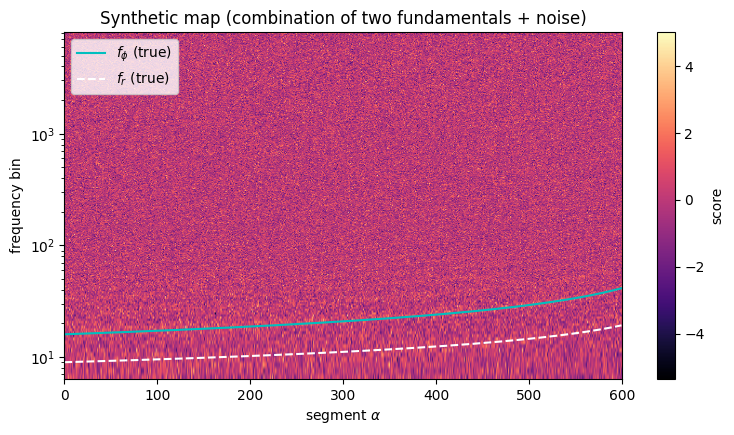

In [3]:
fig, ax = plt.subplots(figsize=(9, 4.5))
im = ax.imshow(np.asarray(score_map).T, origin='lower', aspect='auto',
               cmap='magma', extent=[0, N_seg, 0, N_freq])
ax.plot(seg, f_phi_true, 'c-',  lw=1.5, label=r'$f_\phi$ (true)')
ax.plot(seg, f_r_true,   'w--', lw=1.5, label=r'$f_r$ (true)')
ax.set_yscale('log')
ax.set_xlabel('segment $\\alpha$')
ax.set_ylabel('frequency bin')
ax.set_title('Synthetic map (combination of two fundamentals + noise)')
ax.legend(loc='upper left')
fig.colorbar(im, ax=ax, label='score'); plt.show()


Try with a representative EMRI signal and regular noise, increase the  bottom frequency to avoid the low-freq regime where TF-resolution is not great.

## SNR of the injected signal

Before tracking, it is useful to know *how much signal is actually there*. The data model is `score_map = inj_amp * sig_map + noise`, with i.i.d. Gaussian noise of std `noise_sigma` per time-frequency cell. For a known template $s$, the optimal (expected) matched-filter SNR is

$$\rho = \sqrt{\langle s\,|\,s\rangle},\qquad \langle a\,|\,b\rangle=\sum_{\alpha,k}\frac{a_{\alpha k}\,b_{\alpha k}}{\sigma_n^2},$$

i.e. the Frobenius norm of the noise-free signal map in units of the per-cell noise. This is the SNR a filter that knew the exact comb would collect; the semi-coherent Viterbi recovers a fraction of it.

The breakdown below makes the point of the multi-voice approach quantitative: the **loudest single harmonic** sits at modest SNR and the median line is essentially buried, yet the **whole comb** is a confident detection. If the lines were perfectly resolved they would be orthogonal and $\rho_\text{tot}=\sqrt{\sum_{mn}\rho_{mn}^2}$; here several harmonics overlap (line width $\sigma=1.2$ bins) and add constructively, so the quadrature sum is a **lower bound** and the full comb sits above it.


In [4]:
def injected_snr(inj_amp, sig_map, noise_sigma):
    """Optimal matched-filter SNR of the full injected comb in the score map.

    Data model:  score_map = inj_amp * sig_map + N(0, noise_sigma**2) per cell.
    For a known template s the optimal (expected) matched-filter SNR is
        rho = sqrt(<s|s>),   <a|b> = sum_cells a*b / noise_sigma**2,
    i.e. the Frobenius norm of the signal map in units of the per-cell noise.
    This is the SNR available to a filter that knows the exact comb; the
    semi-coherent Viterbi statistic recovers a fraction of it.
    """
    s = inj_amp * np.asarray(sig_map)
    return float(np.sqrt(np.sum(s ** 2)) / noise_sigma)


def per_harmonic_snr(inj_amp, noise_sigma):
    """Matched-filter SNR carried by each individual harmonic line (m, n)."""
    rhos = []
    for (m, n, a) in zip(m_arr, n_arr, amp_mode):
        fmn = m * f_phi_true + n * f_r_true
        in_band = (fmn >= 0) & (fmn < N_freq)
        line = inj_amp * a * np.exp(-0.5 * ((freq[None, :] - fmn[:, None]) / sigma) ** 2)
        line = np.where(in_band[:, None], line, 0.0)
        rhos.append(np.sqrt(np.sum(line ** 2)) / noise_sigma)
    return np.array(rhos)


rho_tot  = injected_snr(inj_amp, sig_map, noise_sigma)
rho_harm = per_harmonic_snr(inj_amp, noise_sigma)
i_dom    = int(np.argmax(rho_harm))

print(f"optimal matched-filter SNR of the full comb : rho = {rho_tot:6.1f}")
print(f"loudest single harmonic (m,n)=({int(m_arr[i_dom])},{int(n_arr[i_dom])})        : "
      f"rho = {rho_harm[i_dom]:6.1f}")
print(f"median single-harmonic SNR                  : rho = {np.median(rho_harm):6.1f}")
print(f"quadrature sum sqrt(sum rho_mn^2)           : rho = {np.sqrt(np.sum(rho_harm ** 2)):6.1f}"
      "   (lower bound; full comb is larger where nearby lines overlap)")
print("\n-> no single line is loud, but the comb together is a confident signal:"
      "\n   this is exactly the SNR budget the multi-voice Viterbi is built to collect.")


optimal matched-filter SNR of the full comb : rho =   40.1
loudest single harmonic (m,n)=(1,0)        : rho =   21.4
median single-harmonic SNR                  : rho =    3.8
quadrature sum sqrt(sum rho_mn^2)           : rho =   30.4   (lower bound; full comb is larger where nearby lines overlap)

-> no single line is loud, but the comb together is a confident signal:
   this is exactly the SNR budget the multi-voice Viterbi is built to collect.


## Viterbi forward pass 

Given an emission array `emission` of shape `(N_seg, S)` and a log-transition matrix `log_trans` of shape `(S_prev, S_next)` (`0` where a move is allowed, `-inf` where forbidden), the Bellman recursion is defined as 

$$V_\alpha(s) = E_\alpha(s) + \max_{s'} \big[V_{\alpha-1}(s') + \log T(s'\to s)\big].$$

The forward pass stores, for every segment and every state, the argmax predecessor (the backpointer). Backtracking from the best final state then reconstructs the optimal path. The forward pass is the part worth accelerating, so it lives in `lax.scan`. the backtrack is a cheap loop on the host.


In [5]:
def viterbi_forward(emission, log_trans):
    # Hard-max forward pass. Returns (V_last, backpointers).
    def step(V_prev, E_a):
        scores    = V_prev[:, None] + log_trans      # (S_prev, S_next)
        best_prev = jnp.argmax(scores, axis=0)       # (S_next,)
        V         = E_a + jnp.max(scores, axis=0)     # (S_next,)
        return V, best_prev
    V0 = emission[0]   # no transition into segment 0
    V_last, backptrs = lax.scan(step, V0, emission[1:])
    return V_last, backptrs   # backptrs: (N_seg-1, S)

def viterbi_backtrack(V_last, backptrs):
    # Host-side backtrack: integer state path of length N_seg.
    backptrs = np.asarray(backptrs)
    N = backptrs.shape[0] + 1
    path = np.empty(N, dtype=int)
    path[-1] = int(jnp.argmax(V_last))
    for i in range(N - 2, -1, -1):
        path[i] = backptrs[i][path[i + 1]]
    return path

viterbi_forward = jax.jit(viterbi_forward)


## First only consider single-tracks
This is the standard Viterbi tracker as used in CW searches. 

State = a single frequency bin. 
Emission = the raw score map. 
Transitions enforce the following constraints:
- chirp-up 
- continuity**: $0 \le k-k' \le \Delta_{\max}$ (frequency may only rise, by at most a few bins per segment). 

This positive $\dot{f}$ only holds for the fundamental frequency, as negative $n$-modes may cause tracks to ani-chirp. With no single brightest harmonic carrying enough SNR, it latches onto whichever comb line is locally brightest and jumps or wanders between lines. There is no constraint holding the lines together. 


In [6]:
dmax = 6
k = np.arange(N_freq)
dk = k[None, :] - k[:, None]                       # next - prev
allow = (dk >= 0) & (dk <= dmax)
log_trans_1d = jnp.asarray(np.where(allow, 0.0, -np.inf))

V_last_1d, bp_1d = viterbi_forward(score_map, log_trans_1d)
path_1d = viterbi_backtrack(V_last_1d, bp_1d)         # freq bin per segment


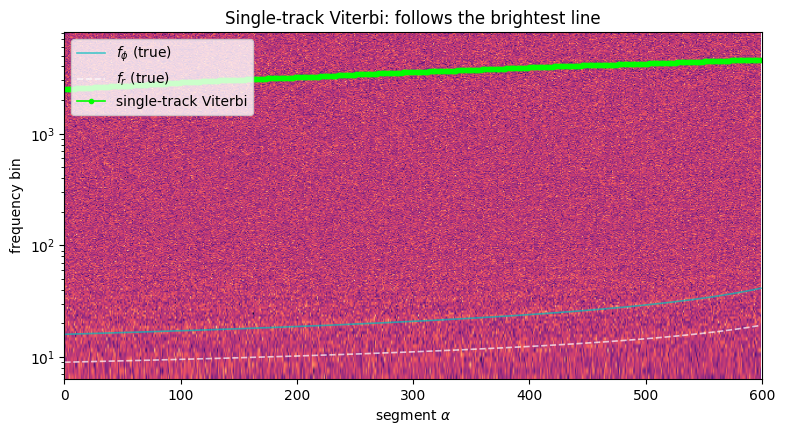

In [7]:
# make plot of random single track Viterbi path
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.imshow(np.asarray(score_map).T, origin='lower', aspect='auto', cmap='magma',
          extent=[0, N_seg, 0, N_freq])
ax.plot(seg, f_phi_true, 'c-',  lw=1.2, alpha=0.7, label=r'$f_\phi$ (true)')
ax.plot(seg, f_r_true,   'w--', lw=1.2, alpha=0.7, label=r'$f_r$ (true)')
ax.plot(seg, path_1d, 'o-', color='lime', ms=3, lw=1.2, label='single-track Viterbi')
ax.set_yscale('log')
ax.set_xlabel('segment $\\alpha$'); ax.set_ylabel('frequency bin')
ax.set_title('Single-track Viterbi: follows the brightest line')
ax.legend(loc='upper left'); plt.show()


This is not a useful result for the EMRI search, but can be a test for the different functions that make up the algorithm and a sanity check for the more cmplex multi-voice version. 

With some playing around with the injection amplitude, we find that the single-track Viterbi algorithm can be far off for low amplitudes. The boundary for "low" seems to be around the point where the dominant line is visually identifiable, which corresponds to injection amplitude $\geq 1.0$ for this toy model. Below that, the single-track Viterbi is essentially following noise fluctuations and can be very far from the true track. 

## Multi-voice Viterbi with constraints

Now the latent state is theset of fundamentals $(f_\phi, f_r)$ on a coarse grid, and the emission sums over a predefined set of combinations tied to that pair:

$$E_\alpha(f_\phi, f_r) = \sum_{(m,n)\in\mathcal H}\; \texttt{score\_map}\big[\alpha,\; m f_\phi + n f_r\big].$$

The combination indices are independent of $\alpha$, so we precompute them once as a `(S, |H|)` integer gather table (out-of-band members are masked, the toy analogue of $A_\alpha$). Transitions factor per fundamental: each index is non-decreasing, enforcing $\dot f > 0$ chirp and bounded, ensuring the continuity. 

This is the simple Viterbi constrained by the multi-voice decomposition: the combination constraint is what lets a pile of individually-buried lines add up to a confident track.


In [8]:
# create joint grid of (f_phi, f_r) pairs
Gphi = 150
Gr = 150
fphi_grid = np.linspace(15.0, 45.0, Gphi)
fr_grid = np.linspace( 5.0, 24.0, Gr)
S= Gphi * Gr
iphi_of_s = np.repeat(np.arange(Gphi), Gr)           # (S,)
ir_of_s = np.tile(np.arange(Gr), Gphi)             # (S,)
FPHI = fphi_grid[iphi_of_s]                     # (S,)
FR = fr_grid[ir_of_s]                         # (S,)

# create combination table over modes: (S, H) table of integer bins to gather from score map
combo = FPHI[:, None] * m_arr[None, :] + FR[:, None] * n_arr[None, :]   # (S, H)
bins  = np.round(combo).astype(int)
valid = (bins >= 0) & (bins < N_freq)

#clip bins to avoid out-of-bounds indexing
bins_clip = np.clip(bins, 0, N_freq - 1)
bins_clip = jnp.asarray(bins_clip); valid_j = jnp.asarray(valid.astype(np.float64))
print(f"S = {S} joint states, comb table {bins_clip.shape}")


S = 22500 joint states, comb table (22500, 27)


In [9]:
# define the multi-voice emission function: get the relevant bins for each join
def multivoice_emission(score_map):
    # get relevant time-frequency bins for each joint state
    g = score_map[:, bins_clip]   # (N_seg, S, H)  
    #summation
    return jnp.sum(g * valid_j[None], axis=-1)        # (N_seg, S)

# post-process transition matrix with constraints enforced
bphi, br = 3, 3
dphi = iphi_of_s[None, :] - iphi_of_s[:, None]
dr = ir_of_s[None, :] - ir_of_s[:, None]
allow2 = (dphi >= 0) & (dphi <= bphi) & (dr >= 0) & (dr <= br)
log_trans_2d = jnp.asarray(np.where(allow2, 0.0, -np.inf))

emission_2d = multivoice_emission(score_map)
V_last_2d, bp_2d = viterbi_forward(emission_2d, log_trans_2d)
path_2d = viterbi_backtrack(V_last_2d, bp_2d)         # joint-state index per segment

fphi_rec = fphi_grid[iphi_of_s[path_2d]]
fr_rec   = fr_grid[ir_of_s[path_2d]]


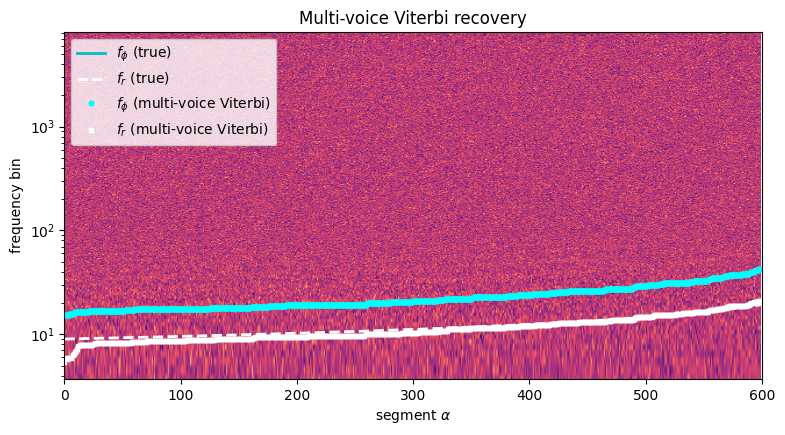

RMS error  f_phi: 0.37 bins   f_r: 0.82 bins (grid spacing 0.20 / 0.13)


In [10]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.imshow(np.asarray(score_map).T, origin='lower', aspect='auto', cmap='magma',
          extent=[0, N_seg, 0, N_freq])

# plot true tracks
ax.plot(seg, f_phi_true, 'c-',  lw=2.0, 
        label=r'$f_\phi$ (true)')
ax.plot(seg, f_r_true, 'w--', lw=2.0, 
        label=r'$f_r$ (true)')

# plot recovered tracks
ax.plot(seg, fphi_rec, 'o', color='cyan',  ms=3.5, 
        label=r'$f_\phi$ (multi-voice Viterbi)')
ax.plot(seg, fr_rec, 's', color='white', ms=3.5, 
        label=r'$f_r$ (multi-voice Viterbi)')

ax.set_yscale('log')
ax.set_xlabel('segment $\\alpha$'); ax.set_ylabel('frequency bin')
ax.set_title('Multi-voice Viterbi recovery')
ax.legend(loc='upper left'); plt.show()

err_phi = np.sqrt(np.mean((fphi_rec - f_phi_true) ** 2))
err_r   = np.sqrt(np.mean((fr_rec   - f_r_true)   ** 2))
print(f"RMS error  f_phi: {err_phi:.2f} bins   f_r: {err_r:.2f} bins "
      f"(grid spacing {fphi_grid[1]-fphi_grid[0]:.2f} / {fr_grid[1]-fr_grid[0]:.2f})")


In [ ]:
"""
Evaluate the SNR accumulation along the true track 
and the expected noise accumulation across frequencies: 
We know the PSD and thus the per bin noise variance. 

Knowing the expected behaviour of the noise curve we can define a deviation metric 
that tells us when a track is accumulating significantly more power than expected from the noise alone. 
This is the basis of the Viterbi score agorithm: it finds the track that maximizes this deviation best. 
"""

## What about $\dot f$? The recovered track is a staircase

The recovered $(f_\phi, f_r)$ looks like a **step function**, and that is *expected* — it is grid quantization, not a failure of the tracker. The latent state lives on a discrete $(f_\phi, f_r)$ grid (here $28\times24$), so the path can only sit on grid values and jump between them. The state has no explicit $\dot f$ dimension: the chirp is encoded only implicitly through the continuity constraint $0\le\Delta i\le b$ on the transitions.

Reading $\dot f$ off such a track by finite differences therefore gives a **staircase derivative**: zero while the path rests on a grid value, then a spike of size $\Delta f_\text{grid}/\Delta t$ at each jump. The *true* $\dot f$ here is smooth and **accelerating** — it rises slowly early on and sweeps up toward the plunge, because the injected tracks are power-law inspiral chirps $f\propto(t_c-t)^{-3/8}$ rather than gentle polynomials. So the question "is the step function expected?" → **yes**; and "do we need a more robust $\dot f$?" → the staircase itself is fine for detection, but to *report* a usable $\dot f$ we should not differentiate the raw path. Three levers, in increasing cost:

1. **Finer $(f_\phi,f_r)$ grid** → smaller steps. Dense transition cost grows as $\mathcal{O}(S^2)$, so this needs the beam search noted in the next-steps section.
2. **Put $\dot f$ in the state** — the real pipeline's $(f_\phi,\dot f_\phi,f_r,\dot f_r)$. Transitions then enforce a smooth chirp and the optimal path tracks the accelerating sweep instead of resting on constant-frequency grid values. This is the principled fix.
3. **Cheap post-processing (shown below):** impose the slow-chirp prior by fitting a low-order polynomial to the recovered samples and differentiating it. Physically justified because $\dot f$ varies slowly over the window, and it turns the staircase into a smooth, accurate $\dot f(t)$ at essentially no cost — a good seed for the gradient refinement and PE stages.

The cell below quantifies all of this: it compares the finite-difference $\dot f$ (staircase) against the smooth-fit $\dot f$, and reports the size of one grid jump in $\dot f$ units.

fdot recovery  [freq-bins per unit time]
  f_phi : finite-diff RMS   50.6   smooth-fit RMS   16.1
  f_r   : finite-diff RMS   33.0   smooth-fit RMS    5.3

one grid jump = a single staircase step in fdot: dphi ~ 121, dr ~ 77
-> the staircase is grid quantization; a smooth slow-chirp fit removes it.


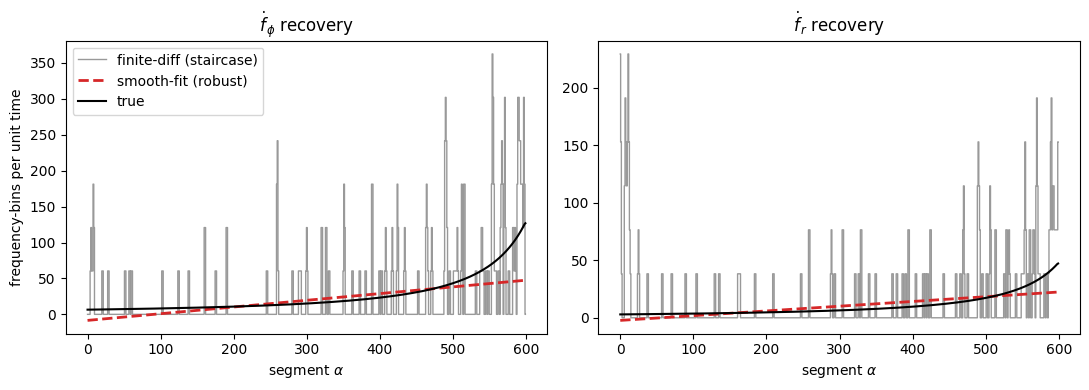

In [12]:
"""true fdot should be smooth: derivative of the injected chirp tracks, 
which is a continuous evolution function at adiabatic order.
The tracks are power-law inspirals, so the true fdot is smooth and 
accelerating, not constant or linear."""
fdot_phi_true = np.gradient(f_phi_true, t)
fdot_r_true   = np.gradient(f_r_true,   t)

# --- fdot read straight off the recovered staircase (finite differences) ---
fdot_phi_fd   = np.gradient(fphi_rec, t)
fdot_r_fd     = np.gradient(fr_rec,   t)

# robust fdot: impose the slow-chirp prior by fitting a low-order
# polynomial to the recovered samples, then differentiate analytically 
deg = 2
cphi = np.polyfit(t, fphi_rec, deg)
cr   = np.polyfit(t, fr_rec,   deg)
fphi_fit, fr_fit = np.polyval(cphi, t), np.polyval(cr, t)
fdot_phi_fit = np.polyval(np.polyder(cphi), t)
fdot_r_fit   = np.polyval(np.polyder(cr),   t)

rms = lambda a, b: float(np.sqrt(np.mean((a - b) ** 2)))
step_phi = (fphi_grid[1] - fphi_grid[0]) / (t[1] - t[0])
step_r   = (fr_grid[1]   - fr_grid[0])   / (t[1] - t[0])
print("fdot recovery  [freq-bins per unit time]")
print(f"  f_phi : finite-diff RMS {rms(fdot_phi_fd, fdot_phi_true):6.1f}   "
      f"smooth-fit RMS {rms(fdot_phi_fit, fdot_phi_true):6.1f}")
print(f"  f_r   : finite-diff RMS {rms(fdot_r_fd,   fdot_r_true):6.1f}   "
      f"smooth-fit RMS {rms(fdot_r_fit,   fdot_r_true):6.1f}")
print(f"\none grid jump = a single staircase step in fdot: "
      f"dphi ~ {step_phi:.0f}, dr ~ {step_r:.0f}")
print("-> the staircase is grid quantization; a smooth slow-chirp fit removes it.")

fig, ax = plt.subplots(1, 2, figsize=(11, 4), sharex=True)
panels = [(fdot_phi_fd, fdot_phi_fit, fdot_phi_true, r'\dot f_\phi'),
          (fdot_r_fd,   fdot_r_fit,   fdot_r_true,   r'\dot f_r')]
for a, (fd, fit, tru, lab) in zip(ax, panels):
    a.plot(seg, fd,  drawstyle='steps-mid', color='0.6', lw=1.0,
           label='finite-diff (staircase)')
    a.plot(seg, fit, 'C3--', lw=2.0, label='smooth-fit (robust)')
    a.plot(seg, tru, 'k-',   lw=1.5, label='true')
    a.set_xlabel('segment $\\alpha$'); a.set_title(f'${lab}$ recovery')
ax[0].set_ylabel('frequency-bins per unit time')
ax[0].legend(loc='upper left'); plt.tight_layout(); plt.show()

## Putting $\dot f$ in the state: the emission-based $(f,\dot f)$ Viterbi

This is **lever 2** — the principled fix. We extend each fundamental's latent state from $f$ to $(f,\dot f)$, giving the joint state $(f_\phi,\dot f_\phi,f_r,\dot f_r)$.

**Why $\dot f$ must live in the emission, not just the transition.** At realistic time resolution the frequency drifts by *less than one bin per step*, so a transition that merely penalises $\dot f$ cannot resolve it: the optimal path sits flat and jumps occasionally, and $\dot f$ collapses to a single value (the staircase that survived a transition-only attempt). The fix — and what the real semi-coherent pipeline does — is to make $\dot f$ an **observable**. The data is organised into $N_\text{block}$ semi-coherent *blocks* of $K$ fine samples, and a block's score is the matched sum of the comb along the predicted within-block chirp,

$$E_\alpha(f_\phi,\dot f_\phi,f_r,\dot f_r)=\sum_{k\in\alpha}\;\sum_{(m,n)\in\mathcal H}\;\texttt{score}\big[k,\;\lfloor m(f_\phi+\dot f_\phi\,\tau_k)+n(f_r+\dot f_r\,\tau_k)\rceil\big],$$

with $\tau_k$ the fine-time offset within the block. The block power now peaks at the correct $(f,\dot f)$ even when the per-step drift is sub-bin, because it integrates over the whole within-block baseline. This is the toy analogue of the $\lfloor (m f_\phi + n f_r)T_\text{sft}\rfloor$ gather in the next-steps section, with $\dot f$ promoted to a searched dimension.

**Frequency resolution.** The recovered track can only sit on $(f_\phi,f_r)$ grid values, so the grid spacing *is* the staircase step size. We therefore use a finer frequency grid here ($36\times20$ in $f$, was $24\times14$); since the out-of-band comb members are routed to a zero guard bin instead of a separate float64 mask, the larger gather table still fits in memory.

**Transition.** Block-to-block continuity uses soft kinematics $f' \approx f + \dot f\,\Delta t_\text{block}$ with a slowly varying $\dot f$, **plus two hard masks**: (i) *continuity* — the next frequency must lie within a few bins of that kinematic prediction and may only rise, so the track can only step to a handful of adjacent frequency bins rather than hop between comb lines; and (ii) *chirp* — $\dot f$ is non-decreasing ($\dot f_i \ge \dot f_{i-1}$), so the sweep keeps accelerating as a real inspiral does. (We use $\ge$ rather than a strict $>$ because on a discrete $\dot f$ grid a strict increase would dead-end any path already sitting on the top $\dot f$ level.) Over a whole *block* the drift is several bins, so this is well-resolved on the grid.

**Tractability.** The transition still factorises ($\log T_\text{joint}=\log T_\phi+\log T_r$), so each Bellman step costs $S_\phi^2 S_r + S_\phi S_r^2$ rather than $(S_\phi S_r)^2$ — and this returns the *exact* optimum a dense full-4D Viterbi would (the two were checked bit-for-bit identical, since the transition is separable). This is the version that maps onto the eventual HPC semi-coherent + Viterbi script; the chirp-rate track it returns is what seeds the spin parameter in the parismc + fewtrax stage.

### Reusing the same dataset as semi-coherent blocks

No new injection or noise here — the $(f,\dot f)$ Viterbi reuses the **single dataset** built in *Create synthetic data*. The fine series is already organised as `score_fine` of shape $(N_\text{block}, K, N_\text{freq})$, so each row is a semi-coherent *block* of $K$ fine samples. The within-block offsets `tau`, the block-centre times `t_block`, and the fine truth `fphi_fine` / `fr_fine` were all defined there. The coarse `score_map` used earlier is the same data sampled at one point (`kc`) per block.

What changes from here on is only the **search state**: each fundamental's latent state is extended from $f$ to $(f,\dot f)$, and the emission integrates the comb along the predicted within-block chirp.


In [ ]:
#(f, fdot) grids; fdot in physical units (bins per unit t)
#  N-independent

#TODO: refine the range for fdot based on the true tracks and the expected recovery error
# we should have less sringent curvature constraints to allow for better recovery of the frequency evolution, which is the key information
# needed for the inverse problem.

# Finer frequency grids than before (was 24 / 14): the recovered track was a
# coarse staircase because each fundamental could only sit on a grid value, so
# the step size IS the grid spacing. Refining f (not fdot) shrinks the steps;
# the fdot resolution is already pinned by the within-block emission. The cost
# is the (K, H, Sphi, Sr) gather table -- kept affordable by routing out-of-band
# comb members to a zero guard bin (next cell) instead of a separate mask.
Gfphi, Gdphi = 36, 12
Gfr,   Gdr   = 20, 12
fphi_g = np.linspace(15.0, 43.0, Gfphi)
dphi_g = np.linspace(0.0, 1200.0, Gdphi)
fr_g   = np.linspace( 8.0, 21.0, Gfr)
dr_g   = np.linspace(0.0,  500.0, Gdr)
print(f"freq grid spacing  f_phi {fphi_g[1]-fphi_g[0]:.2f} bins   f_r {fr_g[1]-fr_g[0]:.2f} bins")


In [ ]:

def fund_states(fg, dg):
    """Flatten a (frequency, fdot) grid into a 1-D state list."""
    Gf, Gd = len(fg), len(dg)
    return np.repeat(np.arange(Gf), Gd), np.tile(np.arange(Gd), Gf), Gf * Gd
iFphi, iDphi, Sphi = fund_states(fphi_g, dphi_g)
iFr,   iDr,   Sr   = fund_states(fr_g,   dr_g)
Fphi_s, Dphi_s = fphi_g[iFphi], dphi_g[iDphi]      # per-state (f_phi, fdot_phi)
Fr_s,   Dr_s   = fr_g[iFr],     dr_g[iDr]          # per-state (f_r,   fdot_r)

# --- comb gather table along the within-block chirp: (K, H, Sphi, Sr) ---
# Out-of-band comb members are routed to a zero-valued guard bin at index N_freq
# (the score map is padded with one zero column below), so we no longer carry a
# separate float64 validity mask. That halves the gather-table memory and is
# what makes the finer frequency grid affordable.
aphi = Fphi_s[:, None] + Dphi_s[:, None] * tau[None, :]    # within-block f_phi(tau)  (Sphi, K)
ar   = Fr_s[:,   None] + Dr_s[:,   None] * tau[None, :]    # within-block f_r(tau)    (Sr,   K)
H = len(m_arr)
bins = np.empty((K, H, Sphi, Sr), np.int32)
for k in range(K):
    comb = (m_arr[:, None, None] * aphi[None, :, k][:, :, None]
            + n_arr[:, None, None] * ar[None, None, :, k])          # (H, Sphi, Sr)
    rb = np.round(comb)
    in_band = (rb >= 0) & (rb < N_freq)
    bins[k] = np.where(in_band, rb, N_freq).astype(np.int32)        # invalid -> guard bin
bins = jnp.asarray(bins)

# pad the score map with one zero frequency bin: gathers at index N_freq read 0
score_fine_pad = jnp.pad(score_fine, ((0, 0), (0, 0), (0, 1)))

def emission_block(sf_block):                  # sf_block: (K, N_freq+1) -> (Sphi, Sr)
    # matched semi-coherent sum of the comb along the within-block chirp
    def per_k(acc, xs):
        sf_k, b_k = xs                          # (N_freq+1,), (H, Sphi, Sr)
        return acc + jnp.sum(sf_k[b_k], axis=0), None
    E, _ = lax.scan(per_k, jnp.zeros((Sphi, Sr)), (sf_block, bins))
    return E

emission_fd = jax.jit(lambda score: lax.map(emission_block, score))
E_block = emission_fd(score_fine_pad)          # (N_block, Sphi, Sr)
print(f"blocks {N_block} x K {K};  states {Sphi} x {Sr} = {Sphi*Sr};  "
      f"emission {tuple(E_block.shape)};  gather table {bins.shape}")

In [ ]:
# Block-to-block transition, factored across the two fundamentals.
# Over one block the frequency advances by fdot * dt_block (several bins), so the
# kinematics is well-resolved on the grid; fdot itself is pinned by the emission.
dt_block = 1.0 / N_block

def trans_cost(fg, dg, iF, iD, sig_f, sig_a, df_max):
    """Log transition cost between (f, fdot) states of one fundamental.

    Hard constraints (forbidden moves -> -inf):
      * continuity : the next frequency stays within `df_max` bins of the
                     kinematic prediction f + fdot*dt_block, AND the frequency
                     may only rise -- the track moves to a few adjacent bins, it
                     cannot jump across the band or drop.
      * chirp      : fdot is non-decreasing (fdot_next >= fdot_prev), so the
                     sweep keeps accelerating, as a real inspiral does. ('>=',
                     not a strict '>': on a discrete grid a strict increase would
                     dead-end any path sitting on the top fdot level.)
    Inside the allowed band a soft Gaussian cost shapes the path.
    """
    f = fg[iF]; d = dg[iD]
    f_pred = (f + d * dt_block)[:, None]      # f advances by fdot * block duration
    f_next = fg[iF][None, :]; d_next = dg[iD][None, :]
    cost = -((f_next - f_pred) ** 2 / (2 * sig_f ** 2)
             + (d_next - d[:, None]) ** 2 / (2 * sig_a ** 2))
    continuous   = np.abs(f_next - f_pred) <= df_max          # only a few adjacent bins
    chirp_up_f   = f_next >= f[:, None] - 1e-9                # frequency rises
    accelerating = d_next >= d[:, None] - 1e-9                # chirp: fdot must not decrease
    return np.where(continuous & chirp_up_f & accelerating, cost, -np.inf)

# df_max ~ a few score-map bins: tight enough to forbid line-hopping, loose
# enough to bracket the kinematic drift (fdot * dt_block can be several bins).
Tphi = jnp.asarray(trans_cost(fphi_g, dphi_g, iFphi, iDphi, sig_f=1.2, sig_a=18.0, df_max=2.5))
Tr   = jnp.asarray(trans_cost(fr_g,   dr_g,   iFr,   iDr,   sig_f=1.0, sig_a=9.0,  df_max=2.0))

@jax.jit
def viterbi_forward_fd(E):
    # factored Bellman: two small max-plus contractions per block
    def step(V, E_a):                                # V, E_a: (Sphi, Sr)
        sA   = V[:, None, :] + Tphi[:, :, None]      # (a_phi, b_phi, r)
        ptrA = jnp.argmax(sA, 0).astype(jnp.int32)   # best a_phi -> (b_phi, r)
        M    = jnp.max(sA, 0)
        sB   = M[:, :, None] + Tr[None, :, :]        # (phi, a_r, b_r)
        ptrB = jnp.argmax(sB, 1).astype(jnp.int32)   # best a_r -> (phi, b_r)
        W    = jnp.max(sB, 1)
        return E_a + W, (ptrA, ptrB)
    V_last, (pA, pB) = lax.scan(step, E[0], E[1:])
    return V_last, pA, pB

def viterbi_backtrack_fd(V_last, pA, pB):
    V_last = np.asarray(V_last); pA = np.asarray(pA); pB = np.asarray(pB)
    sphi = np.empty(N_block, int); sr = np.empty(N_block, int)
    flat = int(np.argmax(V_last)); sphi[-1], sr[-1] = flat // Sr, flat % Sr
    for kk in range(N_block - 2, -1, -1):
        beta     = pB[kk][sphi[kk + 1], sr[kk + 1]]  # r predecessor (stage B)
        sphi[kk] = pA[kk][sphi[kk + 1], beta]        # phi predecessor (stage A)
        sr[kk]   = beta
    return sphi, sr

V_last_fd, pA, pB = viterbi_forward_fd(E_block)
sphi_path, sr_path = viterbi_backtrack_fd(V_last_fd, pA, pB)

# decode the latent state into (f, fdot) per block
fphi_rec_fd = fphi_g[iFphi[sphi_path]];  fr_rec_fd   = fr_g[iFr[sr_path]]
fdotphi_rec = dphi_g[iDphi[sphi_path]];  fdotr_rec   = dr_g[iDr[sr_path]]   # bins per unit t

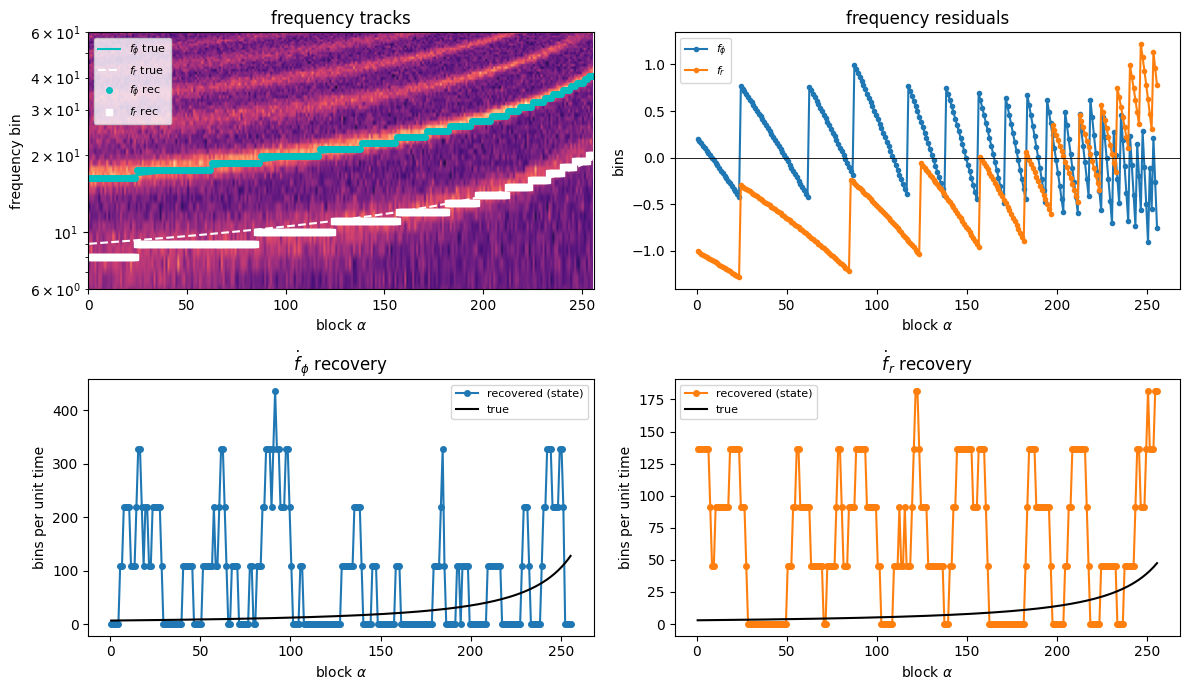

frequency RMS [bins]    f_phi 0.40   f_r 0.68
fdot RMS [bins/unit t]  f_phi 123.3   f_r 76.8   (true fdot_phi spans 7-127)
fdot grid levels used   f_phi 5/12   f_r 5/12

-> fdot is read from the semi-coherent emission (matched within-block chirp), so it no
   longer collapses to one level: a usable chirp-rate track to seed parismc + fewtrax.


In [20]:
# truth sampled at block centres
fphi_ref = np.interp(t_block, t_fine, fphi_fine)
fr_ref   = np.interp(t_block, t_fine, fr_fine)
fdphi_true = np.gradient(fphi_fine, t_fine); fdr_true = np.gradient(fr_fine, t_fine)
fdphi_ref = np.interp(t_block, t_fine, fdphi_true)
fdr_ref   = np.interp(t_block, t_fine, fdr_true)
rms = lambda a, b: float(np.sqrt(np.mean((a - b) ** 2)))
bc  = np.arange(N_block) + 0.5            # block-centre x-coordinates for plotting

fig, ax = plt.subplots(2, 2, figsize=(12, 7))

#frequency tracks over the block-averaged score map 
disp = np.asarray(score_fine).mean(axis=1).T          # (N_freq, N_block)
ax[0, 0].imshow(disp, origin='lower', aspect='auto', cmap='magma',
                extent=[0, N_block, 0, N_freq])
ax[0, 0].plot(bc, fphi_ref, 'c-',  lw=1.5, label=r'$f_\phi$ true')
ax[0, 0].plot(bc, fr_ref,   'w--', lw=1.5, label=r'$f_r$ true')
ax[0, 0].plot(bc, fphi_rec_fd, 'co', ms=4, label=r'$f_\phi$ rec')
ax[0, 0].plot(bc, fr_rec_fd,   'ws', ms=4, label=r'$f_r$ rec')
ax[0, 0].set_yscale('log'); ax[0, 0].set_ylim(6, 60)
ax[0, 0].set_xlabel('block $\\alpha$'); ax[0, 0].set_ylabel('frequency bin')
ax[0, 0].set_title('frequency tracks'); ax[0, 0].legend(loc='upper left', fontsize=8)

# show the frequency residuals 
ax[0, 1].plot(bc, fphi_rec_fd - fphi_ref, 'C0o-', ms=3, label=r'$f_\phi$')
ax[0, 1].plot(bc, fr_rec_fd   - fr_ref,   'C1o-', ms=3, label=r'$f_r$')
ax[0, 1].axhline(0, color='k', lw=0.6)
ax[0, 1].set_xlabel('block $\\alpha$'); ax[0, 1].set_ylabel('bins')
ax[0, 1].set_title('frequency residuals'); ax[0, 1].legend(fontsize=8)

# fdot recovered from the state 
ax[1, 0].plot(bc, fdotphi_rec, 'C0o-', ms=4, label='recovered (state)')
ax[1, 0].plot(bc, fdphi_ref, 'k-', lw=1.5, label='true')
ax[1, 0].set_xlabel('block $\\alpha$'); ax[1, 0].set_ylabel('bins per unit time')
ax[1, 0].set_title(r'$\dot f_\phi$ recovery'); ax[1, 0].legend(fontsize=8)

ax[1, 1].plot(bc, fdotr_rec, 'C1o-', ms=4, label='recovered (state)')
ax[1, 1].plot(bc, fdr_ref, 'k-', lw=1.5, label='true')
ax[1, 1].set_xlabel('block $\\alpha$'); ax[1, 1].set_ylabel('bins per unit time')
ax[1, 1].set_title(r'$\dot f_r$ recovery'); ax[1, 1].legend(fontsize=8)
plt.tight_layout(); plt.show()

print(f"frequency RMS [bins]    f_phi {rms(fphi_rec_fd, fphi_ref):.2f}   f_r {rms(fr_rec_fd, fr_ref):.2f}")
print(f"fdot RMS [bins/unit t]  f_phi {rms(fdotphi_rec, fdphi_ref):.1f}   f_r {rms(fdotr_rec, fdr_ref):.1f}"
      f"   (true fdot_phi spans {fdphi_ref.min():.0f}-{fdphi_ref.max():.0f})")
print(f"fdot grid levels used   f_phi {len(np.unique(fdotphi_rec))}/{Gdphi}   "
      f"f_r {len(np.unique(fdotr_rec))}/{Gdr}")
print("\n-> fdot is read from the semi-coherent emission (matched within-block chirp), so it no"
      "\n   longer collapses to one level: a usable chirp-rate track to seed parismc + fewtrax.")

## Power accumulation along tracks against flattening over noise paths

The current pipeline already lets $\dot f$ vary segment-to-segment (the constant slope is only the *within-bin* slow-chirp approximation) and prunes proposed tracks by continuity. What the Viterbi formulation adds is to make that search *optimal and joint*: the Bellman recursion + backtracking return the single best continuity-respecting path rather than a greedily integrated one, and the joint $(f_\phi,f_r)$ emission couples the two fundamentals through the combinations.

The semi-coherent statistic is the running sum of the emission along a track. The recovered path accumulates power steadily. Other random continuity-respecting tracks wander off the combination lines and average out thanks to the noise properties.

In [15]:
emi_np = np.asarray(emission_2d)
cum_rec = np.cumsum(emi_np[seg, path_2d])

# a few random valid (chirp-up, continuity) tracks for comparison
def random_track():
    s = rng.integers(S)
    out = [s]
    for _ in range(N_seg - 1):
        nxt = np.where(np.asarray(log_trans_2d)[s] == 0.0)[0]
        s = rng.choice(nxt) if len(nxt) else s
        out.append(s)
    return np.array(out)


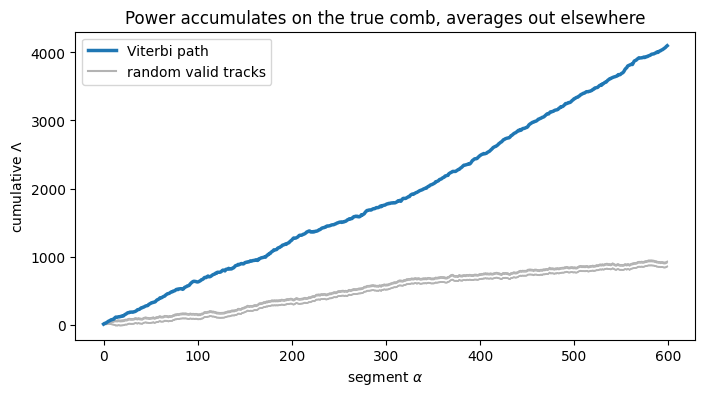

In [16]:

fig, ax = plt.subplots(figsize=(8, 4))
for r in range(6):
    rt = random_track()
    ax.plot(seg, np.cumsum(emi_np[seg, rt]), color='0.7', lw=1)
ax.plot(seg, cum_rec, 'C0-', lw=2.5, label='Viterbi path')
ax.plot([], [], color='0.7', label='random valid tracks')
ax.set_xlabel('segment $\\alpha$'); ax.set_ylabel(r'cumulative $\Lambda$')
ax.set_title('Power accumulates on the true comb, averages out elsewhere')
ax.legend(); plt.show()


## Differentiable Viterbi: backup route

Replacing the hard `max` with a temperature-`logsumexp` makes the forward pass smooth. The useful differentiable knob is not the data but the continuous anchor offset $(\delta_\phi,\delta_r)$ of the two fundamentals: we read the score map at the comb frequencies $m(f_\phi+\delta_\phi)+n(f_r+\delta_r)$ with linear interpolation instead of an integer gather, so the whole `lax.scan` is differentiable in  (\delta_\phi,\delta_r)$. The soft $\log Z$ is then a smooth (non-convex) surface and `jax.grad` flows through. A few gradient steps give a sub-bin refinement of the anchor that the hard Viterbi already localized.

In short: hard Viterbi finds the basin, gradients refine inside it before handing off to parismc. We do not claim the gradient is zero at the true track — the noise realisation displaces the optimum by a fraction of a bin, and that displace optimum is exactly what a refinement step should find. The hard Viterbi remains the primary detector.


grad at (0,0): [-329.47394599  543.7696478 ]  (finite -> differentiable)


refined anchor offset (delta_phi, delta_r) = [-0.179  0.428] bins


soft logZ:  3961.62 (start)  ->  4077.13 (refined)


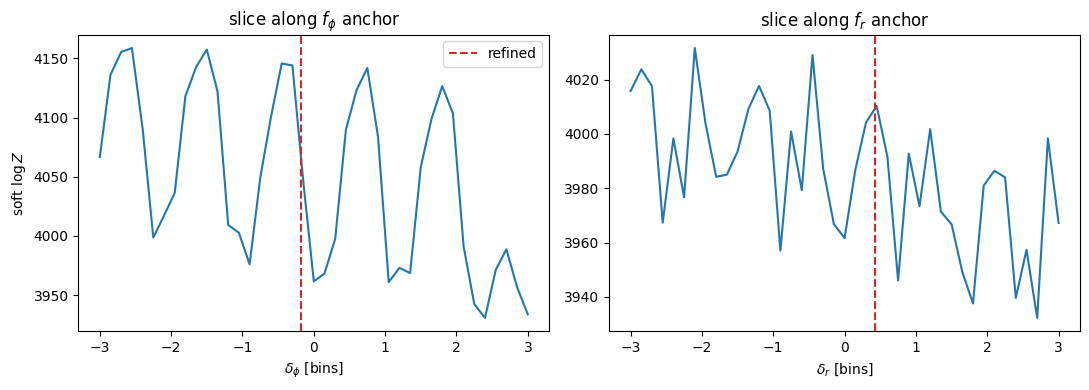

In [17]:
freq_f = jnp.asarray(freq, dtype=jnp.float64)

def emission_smooth(off_phi, off_r):
    # differentiable comb readout: interpolate the map at the *continuous* comb freqs
    cf  = (FPHI + off_phi)[:, None] * m_arr[None] + (FR + off_r)[:, None] * n_arr[None]  # (S,H)
    inb = ((cf >= 0) & (cf < N_freq)).astype(jnp.float64)
    cf_flat = cf.reshape(-1)
    read = jax.vmap(lambda row: jnp.interp(cf_flat, freq_f, row, left=0.0, right=0.0))(score_map)
    return (read.reshape(N_seg, S, -1) * inb[None]).sum(-1)                              # (N_seg,S)

def soft_logZ(off_phi, off_r, tau=2.0):
    e = emission_smooth(off_phi, off_r)
    def step(V, E_a):
        return E_a + (1.0 / tau) * logsumexp(tau * (V[:, None] + log_trans_2d), axis=0), None
    V_last, _ = lax.scan(step, e[0], e[1:])
    return (1.0 / tau) * logsumexp(tau * V_last)

# smooth 1-D slices through the anchor-offset objective
off = np.linspace(-3, 3, 41)
slice_phi = np.array([float(soft_logZ(o, 0.0)) for o in off])
slice_r   = np.array([float(soft_logZ(0.0, o)) for o in off])

# differentiability: gradient flows through the whole forward pass
grad_fn = jax.jit(jax.grad(lambda v: soft_logZ(v[0], v[1])))
print("grad at (0,0):", np.asarray(grad_fn(jnp.array([0.0, 0.0]))), " (finite -> differentiable)")

# a few gradient-ascent steps -> sub-bin refinement of the anchor
v, lr = jnp.array([0.0, 0.0]), 5e-4
logZ0 = float(soft_logZ(v[0], v[1]))
for _ in range(80):
    v = v + lr * grad_fn(v)
print(f"refined anchor offset (delta_phi, delta_r) = {np.asarray(v).round(3)} bins")
print(f"soft logZ:  {logZ0:.2f} (start)  ->  {float(soft_logZ(v[0], v[1])):.2f} (refined)")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(off, slice_phi, 'C0-'); ax[0].axvline(float(v[0]), color='C3', ls='--', label='refined')
ax[0].set_xlabel(r'$\delta_\phi$ [bins]'); ax[0].set_ylabel(r'soft $\log Z$')
ax[0].set_title(r'slice along $f_\phi$ anchor'); ax[0].legend()
ax[1].plot(off, slice_r, 'C0-'); ax[1].axvline(float(v[1]), color='C3', ls='--')
ax[1].set_xlabel(r'$\delta_r$ [bins]'); ax[1].set_title(r'slice along $f_r$ anchor')
plt.tight_layout(); plt.show()


## next steps

To turn this into the real thing, we need to:

1. Emission: Replace the synthetic `score_map` with the per-segment semi-coherent statistic from `emrisearch`. We can use `det_stat` for one voice, or the `multi_harmonic_per_mode` combination sum. The gather table `bins_clip` becomes the set of SFT bins $\lfloor (m f_\phi + n f_r) T_{\mathrm{sft}}\rfloor$, and `valid_j` becomes the real $A_\alpha$ band/slow-chirp mask.
2. State: Extend $(f_\phi, f_r)$ to the full $(f_\phi,\dot f_\phi,f_r,\dot f_r)$
3. Pruning: Swap the dense `(S,S)` transition for beam search: keep the top-$B$ states. We can prune at a fixed cadence (e.g. one month of accumulated data). Cost drops to $\mathcal O(N\,B\,|\text{fan-out}|)$. depending on the grid resolution this is a huge saving or rather an optimization step. 

The hard-Viterbi track from this stage is the best-guess $(f_\phi,f_r)(t)$, which we can hand to the inverse problem solver sampler (parismc + fewtrax), whose posterior then feeds into a full PE run with the WDM-basis waveform likelihood.
